# 08 — McKinsey Style
**Goal:** Replicar el estilo visual de presentaciones de consultoría de alto nivel (McKinsey, BCG, Bain).

## ¿Qué hace diferente a un chart de McKinsey?

| Elemento | Dashboard común | McKinsey |
|---|---|---|
| Título | Describe el chart | **Afirma la conclusión** |
| Colores | Paleta amplia | 1-2 colores, el resto gris |
| Grid | Siempre visible | Mínimo o ausente |
| Datos | Todos iguales | El punto clave, destacado |
| Fuente | Implícita | Siempre explícita |
| Espacio | Comprimido | Generoso — respira |

**Principio central:** el chart debe comunicar UNA sola idea. Todo lo demás es ruido.

In [10]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
from pathlib import Path

Path('data').mkdir(exist_ok=True)
np.random.seed(42)

# Paleta McKinsey
MK = {
    'blue':      '#005587',   # azul primario
    'blue_light':'#4d9db4',   # azul secundario
    'gray_dark': '#404040',   # texto y barras neutras
    'gray_mid':  '#919191',   # elementos secundarios
    'gray_light':'#d9d9d9',   # fondo de barras no destacadas
    'white':     '#ffffff',
    'black':     '#1a1a1a',
    'red':       '#c0392b',   # alerta / negativo
    'green':     '#1a7a4a',   # positivo
}

# rcParams base McKinsey
plt.rcParams.update({
    'figure.facecolor':    MK['white'],
    'axes.facecolor':      MK['white'],
    'font.family':         'Avenir Next',
    'font.size':           10,
    'axes.titlesize':      11,
    'axes.spines.top':     False,
    'axes.spines.right':   False,
    'axes.spines.left':    False,
    'axes.spines.bottom':  True,
    'axes.grid':           False,
    'xtick.bottom':        False,
    'ytick.left':          False,
    'legend.frameon':      False,
    'figure.dpi':          150,
})

# Datos fintech
channels    = ['Email', 'Organic', 'Paid', 'Direct', 'Referral']
activations = [3820, 2940, 2310, 1560, 430]
cvr         = [8.4, 4.2, 5.1, 3.8, 2.9]
months      = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun']
trend       = [1820, 2100, 1950, 2450, 2800, 3100]
target      = [2000, 2200, 2200, 2400, 2600, 2800]

print('Setup listo')

Setup listo


## 1 — El título como conclusión
El cambio más impactante: el título no describe el chart, afirma la historia.

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_6419/478937719.py:29: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Avenir Next.
  plt.tight_layout()
/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_6419/478937719.py:30: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Avenir Next.
  plt.savefig('data/08_mk_title.png', dpi=150, bbox_inches='tight')
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8592 (\N{LEFTWARDS ARROW}) missing from font(s) Avenir Next.
  fig.canvas.print_figure(bytes_io, **kw)


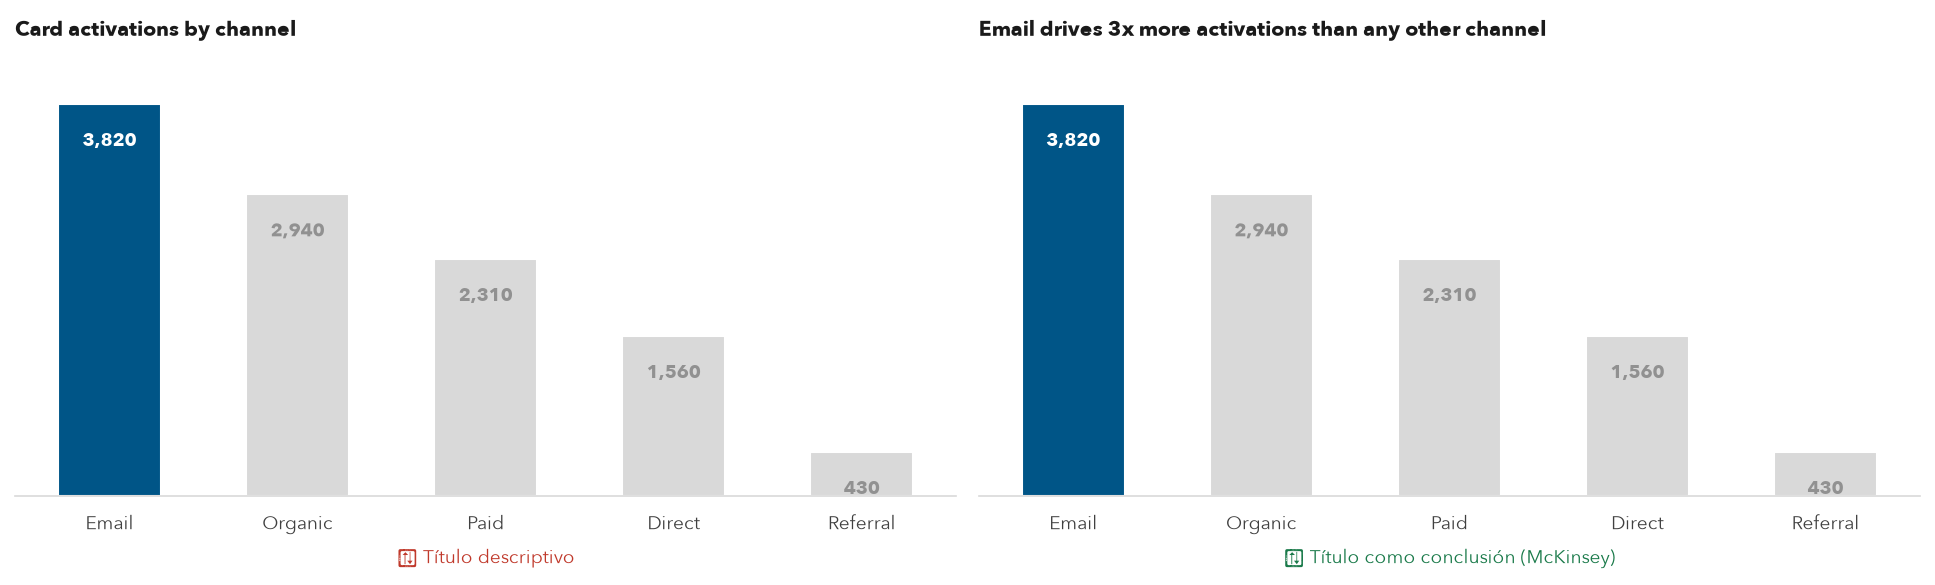

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, title in zip(axes, [
    'Card activations by channel',                          # descriptivo — malo
    'Email drives 3x more activations than any other channel',  # conclusión — bueno
]):
    # Highlight solo Email, el resto gris
    colors = [MK['blue'] if c == 'Email' else MK['gray_light'] for c in channels]
    bars = ax.bar(channels, activations, color=colors, edgecolor=MK['white'], width=0.55)

    # Value labels
    for bar, val in zip(bars, activations):
        color = MK['white'] if val == max(activations) else MK['gray_mid']
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() - max(activations)*0.06,
                f'{val:,}', ha='center', va='top', fontsize=9,
                fontweight='bold', color=color)

    ax.set_title(title, fontsize=10, fontweight='bold', color=MK['black'],
                 loc='left', pad=10)
    ax.set_ylim(0, max(activations) * 1.12)
    ax.yaxis.set_visible(False)
    ax.spines['bottom'].set_color(MK['gray_light'])
    ax.tick_params(axis='x', colors=MK['gray_dark'], labelsize=9)

axes[0].set_xlabel('← Título descriptivo', fontsize=9, color=MK['red'])
axes[1].set_xlabel('← Título como conclusión (McKinsey)', fontsize=9, color=MK['green'])

plt.tight_layout()
plt.savefig('data/08_mk_title.png', dpi=150, bbox_inches='tight')
plt.show()

## 2 — Highlight: un color, el resto gris
La regla de oro del estilo consultoría: solo el dato que importa tiene color.

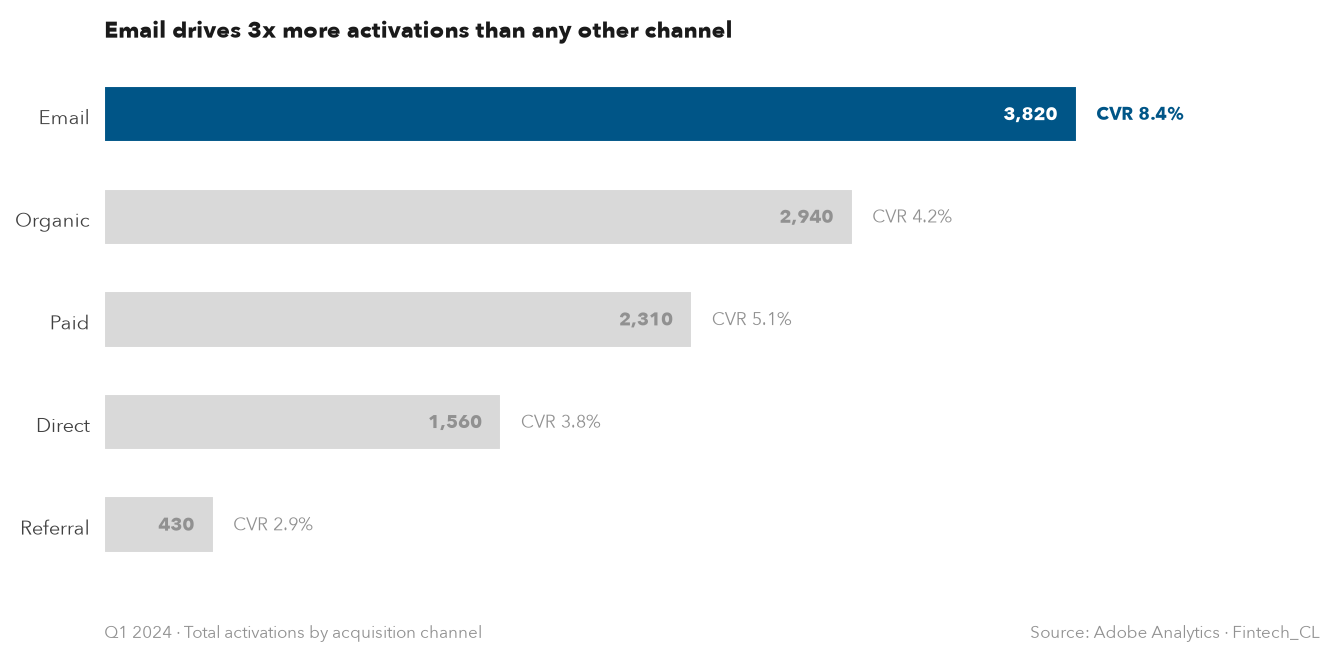

In [12]:
fig, ax = plt.subplots(figsize=(9, 4.5))

# Ordenar de mayor a menor
order = sorted(range(len(activations)), key=lambda i: activations[i], reverse=True)
ch_sorted  = [channels[i] for i in order]
val_sorted = [activations[i] for i in order]
cvr_sorted = [cvr[i] for i in order]

colors = [MK['blue'] if ch == 'Email' else MK['gray_light'] for ch in ch_sorted]
bars   = ax.barh(ch_sorted[::-1], val_sorted[::-1], color=colors[::-1],
                 edgecolor=MK['white'], height=0.55)

# Value labels dentro de la barra
for bar, val, cvr_val, ch in zip(bars, val_sorted[::-1], cvr_sorted[::-1], ch_sorted[::-1]):
    is_top = ch == 'Email'
    ax.text(bar.get_width() - max(val_sorted)*0.02, bar.get_y() + bar.get_height()/2,
            f'{val:,}', ha='right', va='center', fontsize=9,
            fontweight='bold', color=MK['white'] if is_top else MK['gray_mid'])
    # CVR annotation a la derecha
    ax.text(bar.get_width() + max(val_sorted)*0.02, bar.get_y() + bar.get_height()/2,
            f'CVR {cvr_val}%', ha='left', va='center', fontsize=8.5,
            color=MK['blue'] if is_top else MK['gray_mid'],
            fontweight='bold' if is_top else 'normal')

ax.set_title('Email drives 3x more activations than any other channel',
             fontsize=11, fontweight='bold', color=MK['black'], loc='left', pad=12)
ax.text(0, -0.12, 'Q1 2024 · Total activations by acquisition channel',
        transform=ax.transAxes, fontsize=8, color=MK['gray_mid'])
ax.text(1, -0.12, 'Source: Adobe Analytics · Fintech_CL',
        transform=ax.transAxes, fontsize=8, color=MK['gray_mid'], ha='right')

ax.set_xlim(0, max(val_sorted) * 1.25)
ax.xaxis.set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.tick_params(axis='y', colors=MK['gray_dark'], labelsize=9.5)

plt.tight_layout()
plt.savefig('data/08_mk_highlight.png', dpi=150, bbox_inches='tight')
plt.show()

## 3 — Línea de tendencia: real vs target

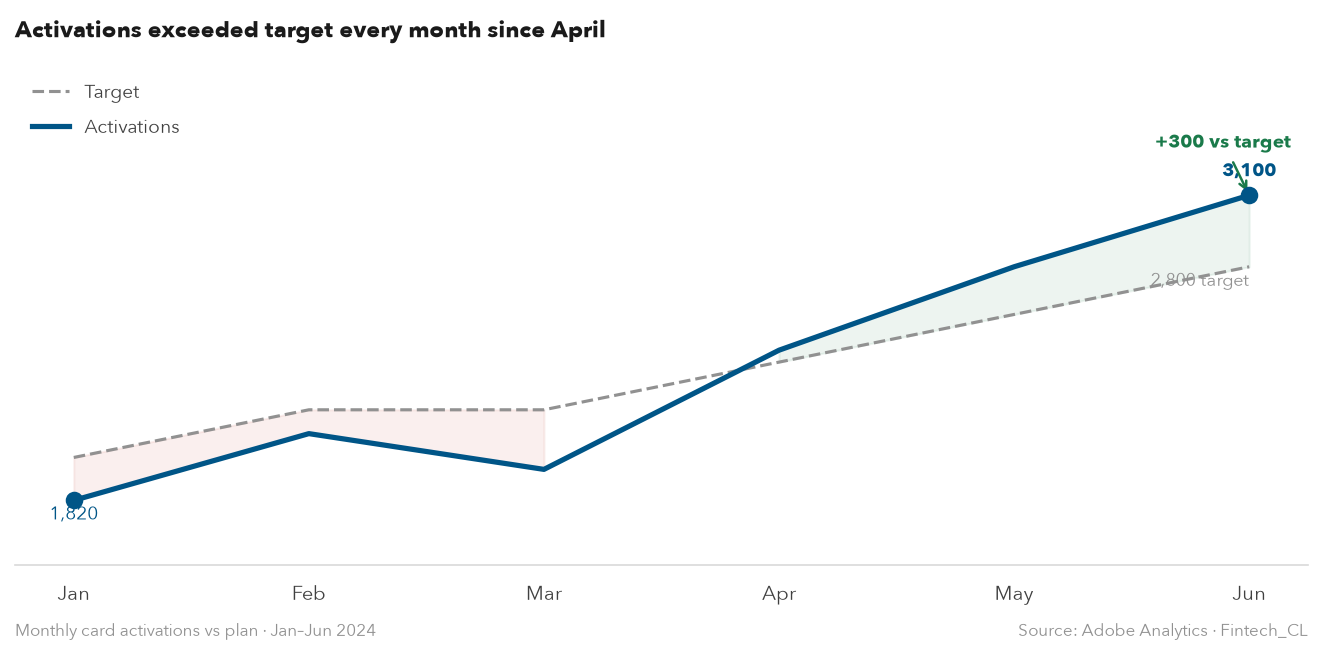

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))

x = np.arange(len(months))

# Área entre real y target
ax.fill_between(x, trend, target,
                where=[t > r for t, r in zip(target, trend)],
                alpha=0.08, color=MK['red'],   label='_gap_neg')
ax.fill_between(x, trend, target,
                where=[t <= r for t, r in zip(target, trend)],
                alpha=0.08, color=MK['green'], label='_gap_pos')

# Líneas
ax.plot(x, target, color=MK['gray_mid'], linewidth=1.5,
        linestyle='--', label='Target')
ax.plot(x, trend,  color=MK['blue'],     linewidth=2.5, label='Activations')

# Markers solo en los extremos
ax.scatter([0, len(months)-1], [trend[0], trend[-1]],
           color=MK['blue'], s=55, zorder=5)

# Etiquetas en los extremos
ax.text(0,              trend[0]  - 80,  f'{trend[0]:,}',  fontsize=9, color=MK['blue'],    ha='center')
ax.text(len(months)-1,  trend[-1] + 80,  f'{trend[-1]:,}', fontsize=9, color=MK['blue'],    ha='center', fontweight='bold')
ax.text(len(months)-1,  target[-1]- 80,  f'{target[-1]:,} target', fontsize=8.5,
        color=MK['gray_mid'], ha='right')

# Anotación del delta
gap = trend[-1] - target[-1]
ax.annotate(f'+{gap:,} vs target',
            xy=(len(months)-1, trend[-1]),
            xytext=(len(months)-1.4, trend[-1] + 200),
            fontsize=9, color=MK['green'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=MK['green'], lw=1.2))

ax.set_title('Activations exceeded target every month since April',
             fontsize=11, fontweight='bold', color=MK['black'], loc='left', pad=12)
ax.text(0, -0.14, 'Monthly card activations vs plan · Jan–Jun 2024',
        transform=ax.transAxes, fontsize=8, color=MK['gray_mid'])
ax.text(1, -0.14, 'Source: Adobe Analytics · Fintech_CL',
        transform=ax.transAxes, fontsize=8, color=MK['gray_mid'], ha='right')

ax.set_xticks(x)
ax.set_xticklabels(months, fontsize=9.5, color=MK['gray_dark'])
ax.set_ylim(min(min(trend),min(target)) * 0.85, max(max(trend),max(target)) * 1.18)
ax.yaxis.set_visible(False)
ax.legend(loc='upper left', fontsize=9, labelcolor=MK['gray_dark'])
ax.spines['bottom'].set_color(MK['gray_light'])

plt.tight_layout()
plt.savefig('data/08_mk_trend.png', dpi=150, bbox_inches='tight')
plt.show()

## 4 — Waterfall: descomposición de un cambio

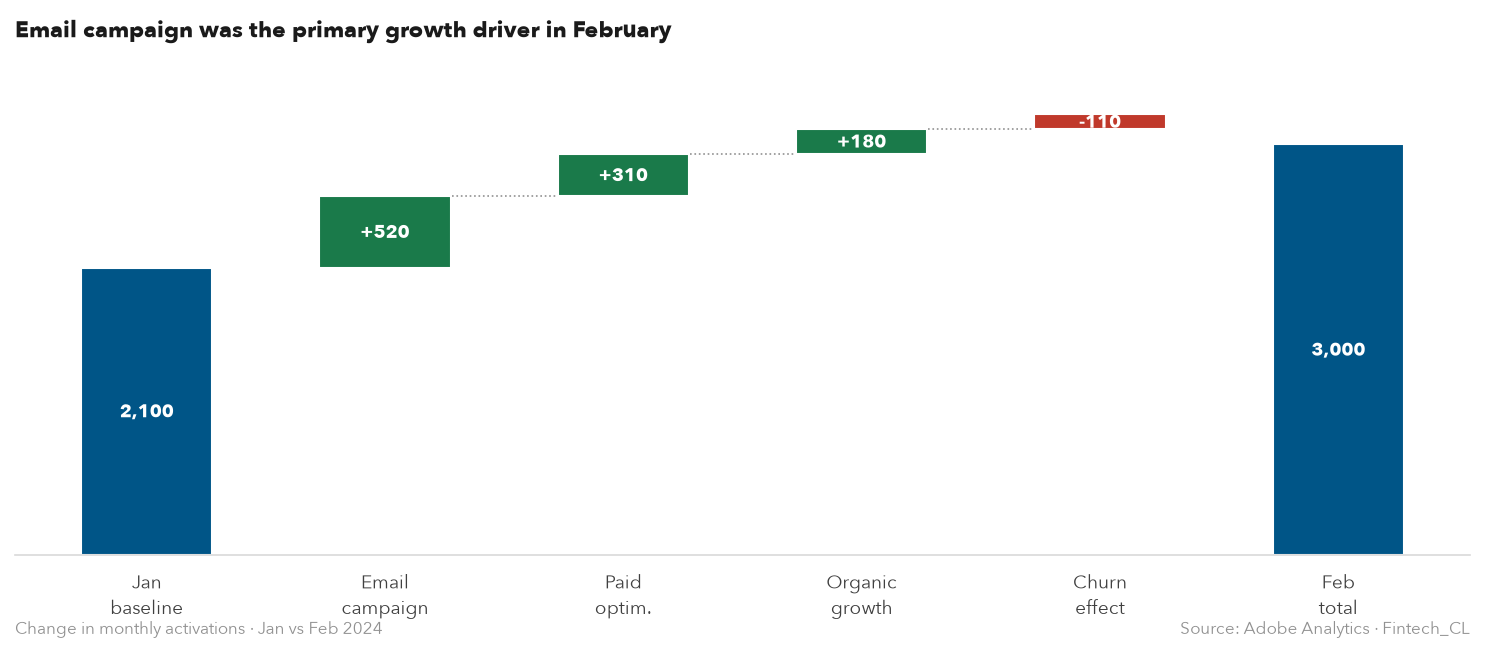

In [14]:
# Descomposición de variación de activaciones vs mes anterior
labels  = ['Jan\nbaseline', 'Email\ncampaign', 'Paid\noptim.', 'Organic\ngrowth', 'Churn\neffect', 'Feb\ntotal']
values  = [2100, +520, +310, +180, -110, 0]
values[-1] = sum(values[:-1])   # total

fig, ax = plt.subplots(figsize=(10, 4.5))

running = values[0]   # inicia en el baseline, no en 0
for i, (label, val) in enumerate(zip(labels, values)):
    is_total    = i == 0 or i == len(labels) - 1
    is_positive = val >= 0

    if is_total:
        bottom = 0
        height = val
        color  = MK['blue']
    else:
        bottom = running
        height = abs(val)
        color  = MK['green'] if is_positive else MK['red']

    ax.bar(i, height, bottom=bottom, color=color, edgecolor=MK['white'], width=0.55)

    # Etiqueta centrada en la barra
    label_y = bottom + height / 2
    prefix  = '+' if val > 0 and not is_total else ''
    ax.text(i, label_y, f'{prefix}{val:,}',
            ha='center', va='center', fontsize=9, fontweight='bold', color=MK['white'])

    # Conector horizontal al siguiente bar (excepto desde/hacia totales)
    if not is_total and i < len(labels) - 2:
        next_y = running + val
        ax.plot([i + 0.28, i + 0.72], [next_y, next_y],
                color=MK['gray_mid'], linewidth=0.8, linestyle=':')

    if not is_total:
        running += val

ax.set_title('Email campaign was the primary growth driver in February',
             fontsize=11, fontweight='bold', color=MK['black'], loc='left', pad=12)
ax.text(0, -0.16, 'Change in monthly activations · Jan vs Feb 2024',
        transform=ax.transAxes, fontsize=8, color=MK['gray_mid'])
ax.text(1, -0.16, 'Source: Adobe Analytics · Fintech_CL',
        transform=ax.transAxes, fontsize=8, color=MK['gray_mid'], ha='right')

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=9, color=MK['gray_dark'])
ax.yaxis.set_visible(False)
ax.spines['bottom'].set_color(MK['gray_light'])
ax.set_ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.savefig('data/08_mk_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()

## 5 — Small multiples: comparar segmentos sin sobrecargar

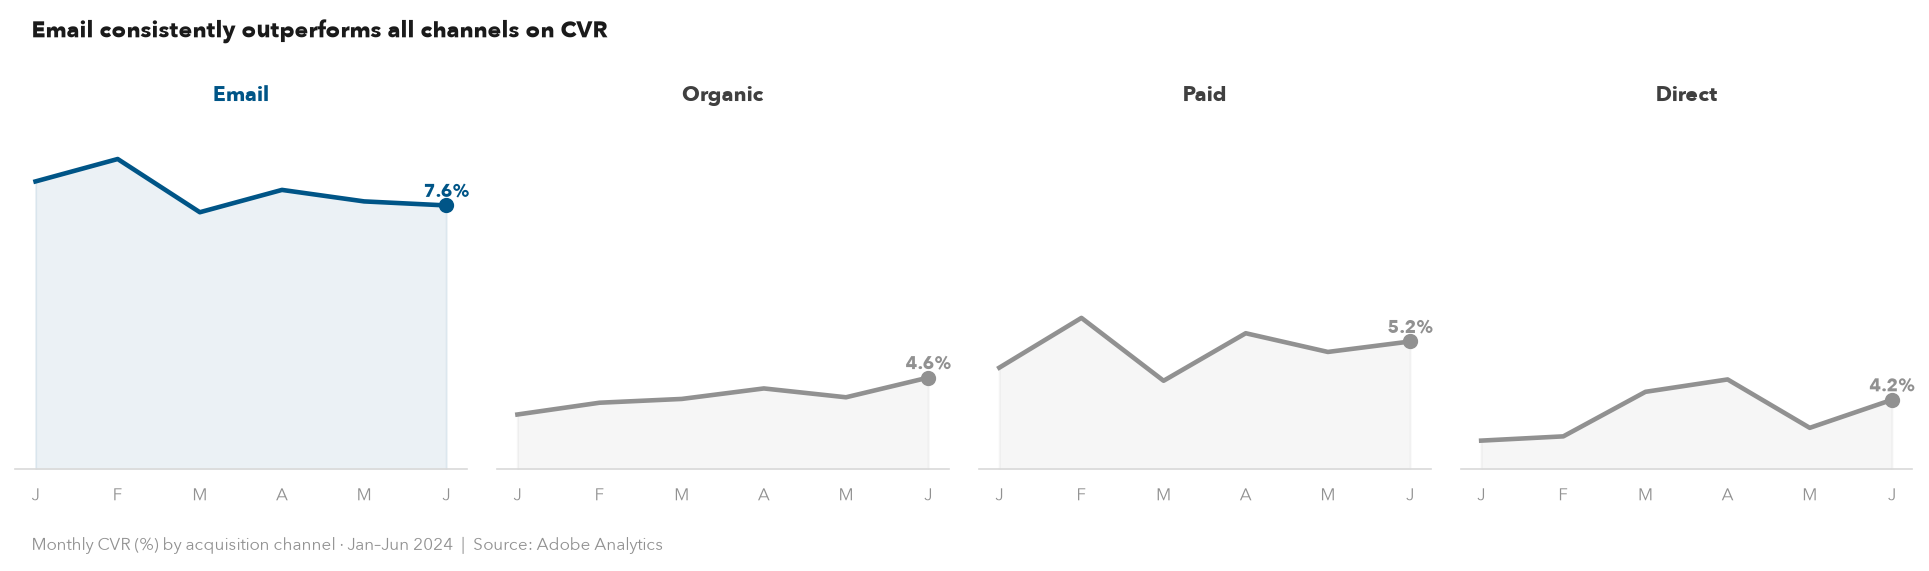

In [15]:
# CVR por canal mes a mes
np.random.seed(1)
channel_list = ['Email', 'Organic', 'Paid', 'Direct']
base_cvr     = {'Email': 8.0, 'Organic': 4.2, 'Paid': 5.0, 'Direct': 3.8}

data = {}
for ch in channel_list:
    data[ch] = [base_cvr[ch] + np.random.uniform(-0.5, 0.8) for _ in months]

fig, axes = plt.subplots(1, 4, figsize=(13, 3.5), sharey=False)

for ax, ch in zip(axes, channel_list):
    vals  = data[ch]
    color = MK['blue'] if ch == 'Email' else MK['gray_mid']

    # Línea del canal
    ax.plot(range(len(months)), vals, color=color, linewidth=2.2)
    ax.fill_between(range(len(months)), vals, alpha=0.08, color=color)

    # Solo valor final
    ax.scatter(len(months)-1, vals[-1], color=color, s=40, zorder=5)
    ax.text(len(months)-1, vals[-1] + 0.15, f'{vals[-1]:.1f}%',
            ha='center', fontsize=8.5, color=color, fontweight='bold')

    ax.set_title(ch, fontsize=10, fontweight='bold',
                 color=MK['blue'] if ch == 'Email' else MK['gray_dark'])
    ax.set_xticks(range(len(months)))
    ax.set_xticklabels([m[0] for m in months], fontsize=8, color=MK['gray_mid'])
    ax.set_ylim(min(min(v) for v in data.values()) - 0.5,
                max(max(v) for v in data.values()) + 0.8)
    ax.spines['bottom'].set_color(MK['gray_light'])
    ax.yaxis.set_visible(False)

fig.suptitle('Email consistently outperforms all channels on CVR',
             fontsize=11, fontweight='bold', color=MK['black'], x=0.02, ha='left')
fig.text(0.02, -0.04, 'Monthly CVR (%) by acquisition channel · Jan–Jun 2024  |  Source: Adobe Analytics',
         fontsize=8, color=MK['gray_mid'])

plt.tight_layout()
plt.savefig('data/08_mk_small_multiples.png', dpi=150, bbox_inches='tight')
plt.show()

## 6 — La diapositiva completa: título + insight box + chart

/var/folders/3m/z0qp5nwj1vlccby390hqt0kc0000gn/T/ipykernel_6419/792801529.py:63: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Avenir Next.
  plt.savefig('data/08_mk_slide_completo.png', dpi=150, bbox_inches='tight',
/Volumes/SSD_Gabo/proyectos/growth-analytics/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8594 (\N{RIGHTWARDS ARROW}) missing from font(s) Avenir Next.
  fig.canvas.print_figure(bytes_io, **kw)


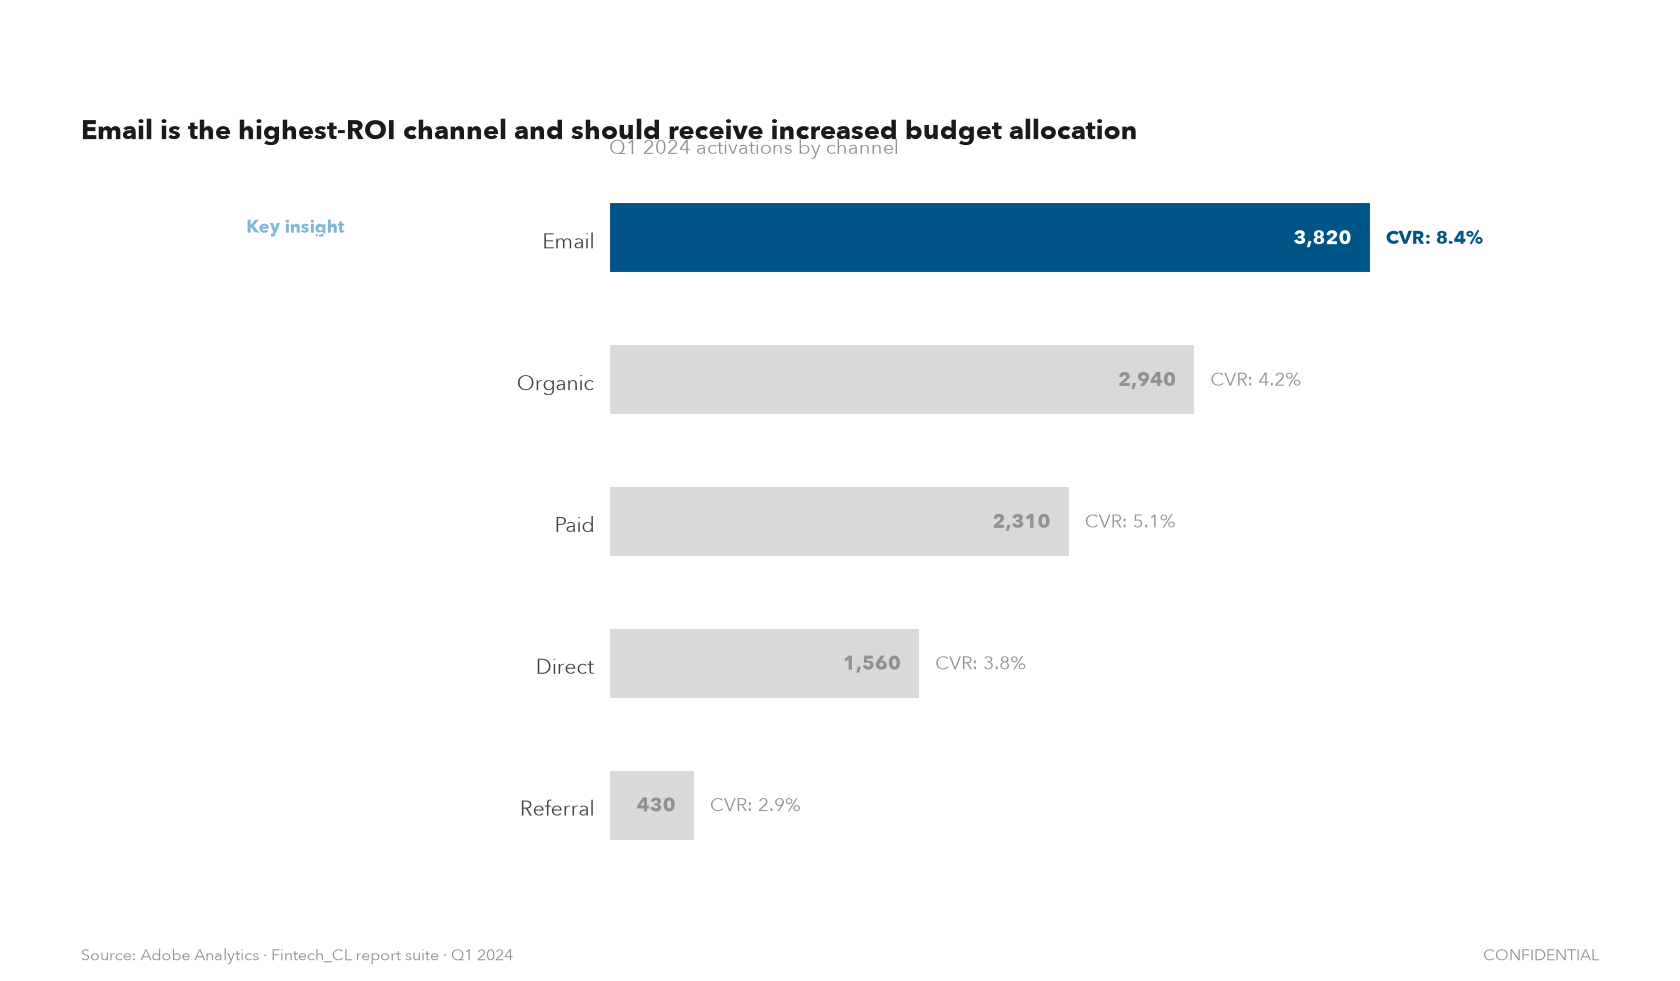

In [16]:
fig = plt.figure(figsize=(11, 6.5), facecolor=MK['white'])

# --- Línea azul superior (sello McKinsey) ---
fig.add_axes([0, 0.97, 1, 0.03]).set_facecolor(MK['blue'])
fig.axes[-1].axis('off')

# --- Título principal ---
fig.text(0.04, 0.90,
         'Email is the highest-ROI channel and should receive increased budget allocation',
         fontsize=13, fontweight='bold', color=MK['black'], va='top', wrap=True)

# --- Insight box (caja azul con la conclusión accionable) ---
insight_ax = fig.add_axes([0.04, 0.60, 0.26, 0.26])
insight_ax.set_facecolor(MK['blue'])
insight_ax.axis('off')
insight_ax.text(0.5, 0.70, 'Key insight',
                ha='center', va='center', fontsize=8.5,
                color='#7fb8d4', fontweight='bold', transform=insight_ax.transAxes)
insight_ax.text(0.5, 0.35,
                'Email delivers 8.4% CVR\n— 2x Paid, 2.2x Organic.\nShifting 20% budget from\nPaid → Email would add\n~600 activations/month.',
                ha='center', va='center', fontsize=8.5,
                color=MK['white'], transform=insight_ax.transAxes,
                linespacing=1.6)

# --- Chart ---
chart_ax = fig.add_axes([0.36, 0.12, 0.60, 0.72])

order    = sorted(range(len(channels)), key=lambda i: activations[i], reverse=True)
ch_s     = [channels[i] for i in order]
val_s    = [activations[i] for i in order]
cvr_s    = [cvr[i] for i in order]
colors_s = [MK['blue'] if c == 'Email' else MK['gray_light'] for c in ch_s]

bars = chart_ax.barh(ch_s[::-1], val_s[::-1], color=colors_s[::-1],
                     edgecolor=MK['white'], height=0.5)

for bar, val, cvr_val, ch in zip(bars, val_s[::-1], cvr_s[::-1], ch_s[::-1]):
    is_top = ch == 'Email'
    chart_ax.text(bar.get_width() - max(val_s)*0.025,
                  bar.get_y() + bar.get_height()/2,
                  f'{val:,}', ha='right', va='center', fontsize=9.5,
                  fontweight='bold', color=MK['white'] if is_top else MK['gray_mid'])
    chart_ax.text(bar.get_width() + max(val_s)*0.02,
                  bar.get_y() + bar.get_height()/2,
                  f'CVR: {cvr_val}%', ha='left', va='center', fontsize=9,
                  color=MK['blue'] if is_top else MK['gray_mid'],
                  fontweight='bold' if is_top else 'normal')

chart_ax.set_xlim(0, max(val_s) * 1.3)
chart_ax.set_title('Q1 2024 activations by channel', fontsize=9.5,
                   color=MK['gray_mid'], loc='left', pad=8)
chart_ax.xaxis.set_visible(False)
chart_ax.spines['bottom'].set_visible(False)
chart_ax.tick_params(axis='y', colors=MK['gray_dark'], labelsize=10)
chart_ax.set_facecolor(MK['white'])

# --- Footer ---
fig.text(0.04, 0.03, 'Source: Adobe Analytics · Fintech_CL report suite · Q1 2024',
         fontsize=7.5, color=MK['gray_mid'])
fig.text(0.96, 0.03, 'CONFIDENTIAL',
         fontsize=7.5, color=MK['gray_mid'], ha='right')

plt.savefig('data/08_mk_slide_completo.png', dpi=150, bbox_inches='tight',
            facecolor=MK['white'])
plt.show()

## 7 — Función `mk_style()` reutilizable

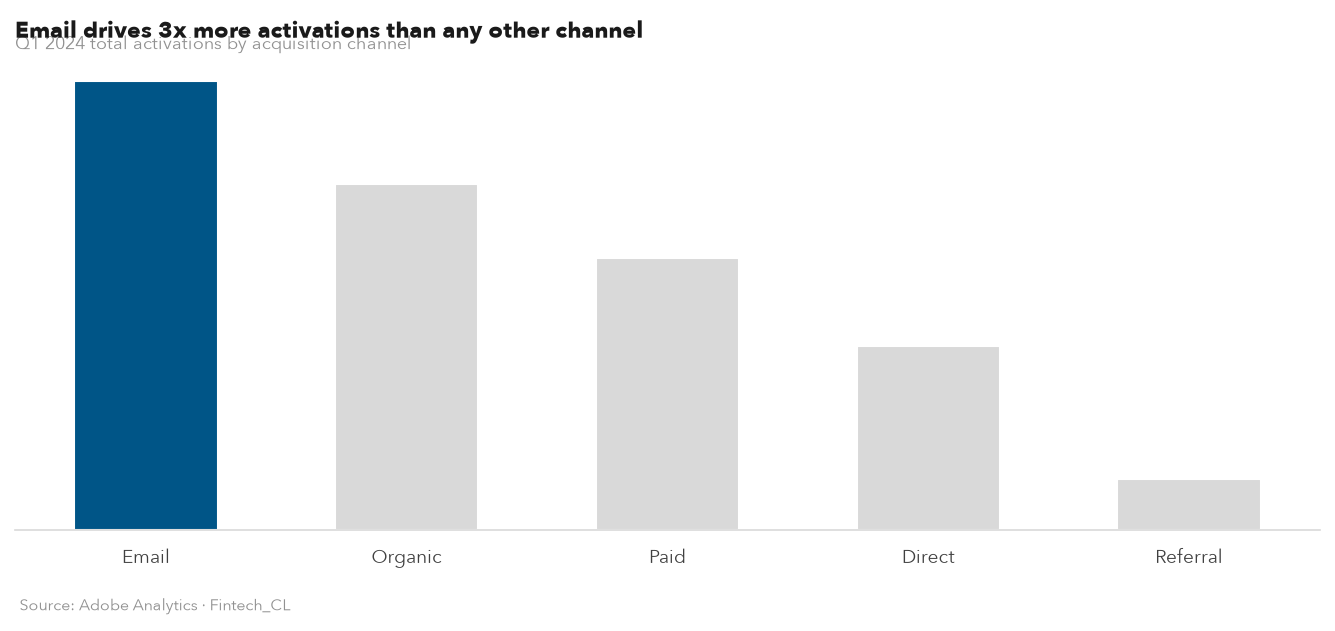

In [17]:
def mk_style(ax, title, subtitle=None, source=None, highlight_bar=None):
    """
    Aplica estilo McKinsey a un axes:
    - Título como conclusión (bold, left-aligned)
    - Subtitle descriptivo debajo (gris, pequeño)
    - Sin grid, sin spines laterales
    - Footer con fuente
    """
    ax.set_title(title, fontsize=11, fontweight='bold',
                 color='#1a1a1a', loc='left', pad=10)

    if subtitle:
        ax.text(0, 1.02, subtitle, transform=ax.transAxes,
                fontsize=8.5, color='#919191')

    if source:
        ax.figure.text(0.02, -0.03, f'Source: {source}',
                       fontsize=7.5, color='#919191')

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.spines['bottom'].set_color('#d9d9d9')
    ax.yaxis.set_visible(False)
    ax.tick_params(axis='x', colors='#404040', labelsize=9)
    ax.grid(False)


# Uso en cualquier chart
fig, ax = plt.subplots(figsize=(9, 4))

colors = [MK['blue'] if c == 'Email' else MK['gray_light'] for c in channels]
ax.bar(channels, activations, color=colors, edgecolor=MK['white'], width=0.55)

mk_style(
    ax,
    title='Email drives 3x more activations than any other channel',
    subtitle='Q1 2024 total activations by acquisition channel',
    source='Adobe Analytics · Fintech_CL',
)

plt.tight_layout()
plt.show()

## Resumen — Checklist McKinsey

Antes de entregar cualquier chart, verifica:

- [ ] **Título = conclusión** — ¿alguien que no vea el chart puede entender el mensaje solo con el título?
- [ ] **Un solo color** — el dato clave en azul, el resto en gris
- [ ] **Sin grid** — o mínimo y en gris claro
- [ ] **Sin ejes Y** — los valores están en las barras/líneas
- [ ] **Subtítulo descriptivo** — qué mide, qué período, qué unidad
- [ ] **Source** — siempre en el footer
- [ ] **Una sola idea** — si el chart necesita dos lecturas, son dos charts

**Estilo McKinsey no es decoración — es disciplina editorial aplicada a datos.**